# Reduced equations (analytic solution)

Let's plot the analytic solution for the reduced equations:

$$ 0 = \frac{\partial \mathcal{W}}{\partial t} = \frac{1}{\Sigma \Omega R^3 } \frac{\partial \mathcal{G}}{\partial R} - \left(\frac{\Omega_z^2 - \Omega^2}{\Omega^2} \right) \frac{i\Omega}2 \mathcal{W}.$$
$$ 0 = \frac{\partial \mathcal{G}}{\partial t} = \frac{\Sigma H^2 \Omega^3 R^3}4 \frac{\partial \mathcal{W}}{\partial R}  - \left( \frac{\kappa^2 - \Omega^2}{\Omega^2} \right) \frac{i\Omega}2 \mathcal{G} - \alpha \Omega \mathcal{G}, $$

This is the same system as the one in `reduced-eqs-zhu2019.ipynb` and `reduced-eqs-steady-state.ipynb`; i.e., a disk with one planet. In this notebook, I'll test our analytic solution (derived on 12/10/25) against our simulations.

# Imports and global parameters

In [2]:
import numpy as np
import pandas as pd
import tables
import time
import math
#import scipy.differentiate
import scipy.integrate as integ
import scipy.interpolate as interp

import matplotlib.pyplot as plt

In [3]:
cs = 0.02 # 0.02
h = cs
alpha = 0.01 # 0.1 # 0.019

# planet parameters
Mp, a = 0.003, 1

# toggle disk gap
use_gap = False

# gravitational softening term in disk potential
soft_term = 0.1

# radius of disk
Rout = 3.5
# radial coordinate of planet
a = 1
# outer boundary for planet's region of influence
delta = a * (4*soft_term)
Rminus = a - delta
Rplus = a + delta

# Disk properties
If we use a gapped density profile, then $\Sigma(R)$ and $H(R)$ enter into the analytic predictions for $\mathcal{W}(R)$ and $\mathcal{G}(R)$.

## Density profile

In [4]:
def Sigma(Rs, use_gap):
    '''
    Returns the disk's background surface density profile.
    If use_gap is False, do not include a gap in the profile.
    
    '''
    
    K, R_a, R_b, D_a, D_b = 19, 0.5, 1.5, 0.1, 0.2
    fgaps = f_gap(Rs, K, R_a, R_b, D_a, D_b, use_gap)
    
    Sigma0 = 1
    
    return Sigma0 * Rs**(-3/2) / fgaps

def f_gap(Rs, K, R_a, R_b, D_a, D_b, use_gap):
    '''
    Function that "shapes" the disk gap profile. Used in `sigma` function. 
    R_a and R_b are the locations of the inner and outer gap edges,
    D_a and D_b are the steepness of the edges, and K determines the
    depth of the gap.
    If use_gap is False, return 1 (i.e., no disk gap).
    
    '''

    if use_gap:
        return 1 + (K-1)/2 * \
            (np.tanh((Rs - R_a)/D_a) - np.tanh((Rs - R_b)/D_b))
    else:
        return 1

## Scale height

In [5]:
def OmegaK(Rs):
    '''
    Returns the Keplerian orbital frequency profile.
    Omega_K = sqrt(G*M_star / R^3)

    '''
    OmegaK_0 = 1 # Omega_K at R=R_0
    return OmegaK_0 * Rs**(-3/2)

def scaleHeight(Rs):
    '''
    Returns the disk's scale height profile. We use H = c_sound / Omega_K.

    '''
    return cs / OmegaK(Rs)

def oneOverSigmaHsquared(R, use_gap):
    '''
    Returns 1/(Sigma * H^2). This function is used when
    calculating W(R) for an arbitrary Sigma profile.

    '''

    return 1 / (Sigma(R,use_gap) * scaleHeight(R)**2)

# Analytic solution

## Define $y, \mathcal{W}(R)$

In [6]:
def ycoord(R):
    '''
    Returns the dimensionless coordinate y(R), where 
    dy = Z(R)dR / ha.
    
    '''

    return Mp/(np.pi * soft_term * h) * \
        np.arctan(((R/a) - 1)/soft_term)
    

k = ycoord(Rplus)

In [7]:
# we impose W_out, from which we can calculate W_in, W_minus, and W_plus
Wout = 0.1
def get_Win(Wout, use_gap=False):
    '''
    Compute W at the inner boundary using W at the outer boundary.
    
    '''

    if use_gap:
        term1 = np.cosh(2*k)
        term2 = 2j*alpha*np.sinh(2*k) * Sigma(a, use_gap)*scaleHeight(a) 
        I = integ.quad(oneOverSigmaHsquared, Rplus, Rout, args=(use_gap,))[0]
        
        return (term1 + term2*I)**(-1) * Wout
    else:
        return (4j * (alpha/h) * (Rout**(1/2) - Rplus**(1/2))/a**(1/2) * np.sinh(2*k) \
            + np.cosh(2*k))**(-1) * Wout

Win = get_Win(Wout, use_gap)
Wminus = Win
Wplus = Wminus * np.cosh(2*k)

In [8]:
def Winner(R):
    '''
    Compute W(R) in the inner region (i.e., R < R_minus).
    
    '''

    ones = np.zeros(np.shape(R)) + 1
    return Win*ones

def Wmid(R):
    '''
    Compute W(R) in the middle region; i.e., the planet's
    region of influence (R_minus < R < R_plus).
    
    '''

    k = ycoord(Rplus)
    y = ycoord(R)
    return Win*np.cosh(y+k)

def Wouter(R, use_gap):
    '''
    Compute W(R) in the outer region (i.e., R > R_plus).
    
    '''

    k = ycoord(Rplus)

    if use_gap:
        term1 = np.cosh(2*k)
        term2 = 2j*alpha*np.sinh(2*k) * Sigma(a, use_gap)*scaleHeight(a) 
        I = integ.quad(oneOverSigmaHsquared, Rplus, R, args=(use_gap,))[0]
        
        return (term1 + term2*I) * Win
    else:
        return (4j*(alpha/h)*(R**(1/2) - Rplus**(1/2))/a**(1/2) * np.sinh(2*k) + \
                np.cosh(2*k)) * Win

# circumvents ValueError
Wouter = np.vectorize(Wouter)

## plot $\mathcal{W}(R)$

In [10]:
## load in (integrated) steady-state solution
load_data = True

if load_data:
    if use_gap:
        file_path_W = "Data/steady-state/RWs/gapped-alpha=" + str(alpha) + \
            ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
                ",Rmax=" + str(Rout) + ".npy"
        file_path_G = "Data/steady-state/RGs/gapped-alpha=" + str(alpha) + \
            ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
                ",Rmax=" + str(Rout) + ".npy"
    else:
        file_path_W = "Data/steady-state/RWs/alpha=" + str(alpha) + \
            ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
                ",Rmax=" + str(Rout) + ".npy"
        file_path_G = "Data/steady-state/RGs/alpha=" + str(alpha) + \
            ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
                ",Rmax=" + str(Rout) + ".npy"
    
    RWs_ss = np.load(file_path_W)
    Rs_ss, Ws_ss = RWs_ss[0], RWs_ss[1]
    
    RGs_ss = np.load(file_path_G)
    Rs_torque_ss, Gs_ss = RGs_ss[0], RGs_ss[1]

In [11]:
# spatial domain
Rmin = 0.5
Rmax = Rout
DeltaR = .01 # 0.03
num_Rs = (int) ((Rmax - Rmin) / DeltaR) + 1

# stagger W and G in the R domain
Rs_warp = np.linspace(Rmin, Rmax, num_Rs)

Rs_inner = Rs_warp[Rs_warp < Rminus]
Rs_outer = Rs_warp[Rs_warp > Rplus]
Rs_mid = Rs_warp[(Rs_warp > Rminus) & (Rs_warp < Rplus)]

/Users/jupiterding/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/jupiterding/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


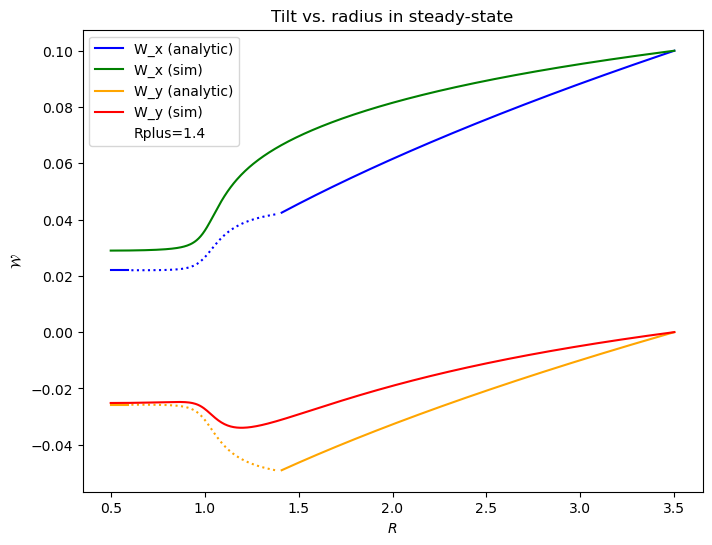

In [12]:
fig, ax = plt.subplots(figsize=(8,6))

plt.plot(Rs_inner, Winner(Rs_inner).real, color="blue", ls='-')
plt.plot(Rs_inner, Winner(Rs_inner).imag, color="orange", ls='-')

plt.plot(Rs_mid, Wmid(Rs_mid).real, color="blue", ls=':')
plt.plot(Rs_mid, Wmid(Rs_mid).imag, color="orange", ls=':')

if load_data:
    plt.plot(Rs_outer, Wouter(Rs_outer, use_gap).real, color="blue", ls='-', label="W_x (analytic)")
    plt.plot(Rs_ss, Ws_ss.real, color="green", label="W_x (sim)")
    plt.plot(Rs_outer, Wouter(Rs_outer, use_gap).imag, color="orange", ls='-', label="W_y (analytic)")
    plt.plot(Rs_ss, Ws_ss.imag, color="red", label="W_y (sim)")
else:
    plt.plot(Rs_outer, Wouter(Rs_outer, use_gap).real, color="blue", ls='-', label="W_x (analytic)")
    plt.plot(Rs_outer, Wouter(Rs_outer, use_gap).imag, color="orange", ls='-', label="W_y (analytic)")

if use_gap:
    R_a, R_b = 0.5, 1.5
    ax.vlines([R_a,R_b], 0, 1, transform=ax.get_xaxis_transform(), \
                  color="black", linestyle=":")#, label="Gap edges")

plt.scatter([],[], s=0, label="Rplus=" + str(Rplus))

plt.title(r"Tilt vs. radius in steady-state")
plt.xlabel(r"$R$")
plt.ylabel(r"$\mathcal{W}$")
plt.legend()

save_figs = True
if save_figs:
    if use_gap:
        filepath = "Figures/gapped-analytic_alpha=" + str(alpha) + \
    ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
        ",Rmax=" + str(Rmax) + ",Rplus=" + str(Rplus) + ".png"
    else:
        filepath = "Figures/analytic_alpha=" + str(alpha) + \
    ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
        ",Rmax=" + str(Rmax) + ",Rplus=" + str(Rplus) + ".png"
    plt.savefig(filepath)
    
plt.show()

## plot $\mathcal{G}(R)$

In [13]:
def Gmid(R, use_gap):
    '''
    Compute G(R) in the middle region; i.e., the planet's
    region of influence (R_minus < R < R_plus).
    
    '''

    k = ycoord(Rplus)
    y = ycoord(R)
    if use_gap: # GM_* = 1
        return (1j/2) * Sigma(a,use_gap) * scaleHeight(a) * Win*np.sinh(y+k)
    else: # Sigma0 = GM_* = a = 1
        return (1j/2) * h * Win*np.sinh(y+k)

def Gouter(R, use_gap):
    '''
    Compute G(R) in the outer region (i.e., R > R_plus).
    
    '''

    # k = ycoord(Rplus)
    # if use_gap:
    #     return ...
    # else:
    #     return (1j/2) * h * Win*np.sinh(2*k) # Sigma0 = GM_* = a = 1

    return np.zeros(R.shape) + Gmid(Rplus, use_gap)

In [14]:
# spatial domain
Rmin = 0.5
Rmax = Rout
DeltaR = .01 # 0.03
num_Rs = (int) ((Rmax - Rmin) / DeltaR) + 1

# stagger W and G in the R domain
Rs_torque = Rs_torque_ss.real.copy()

Rs_inner = Rs_torque[Rs_torque < Rminus]
Rs_outer = Rs_torque[Rs_torque > Rplus]
Rs_mid = Rs_torque[(Rs_torque > Rminus) & (Rs_torque < Rplus)]

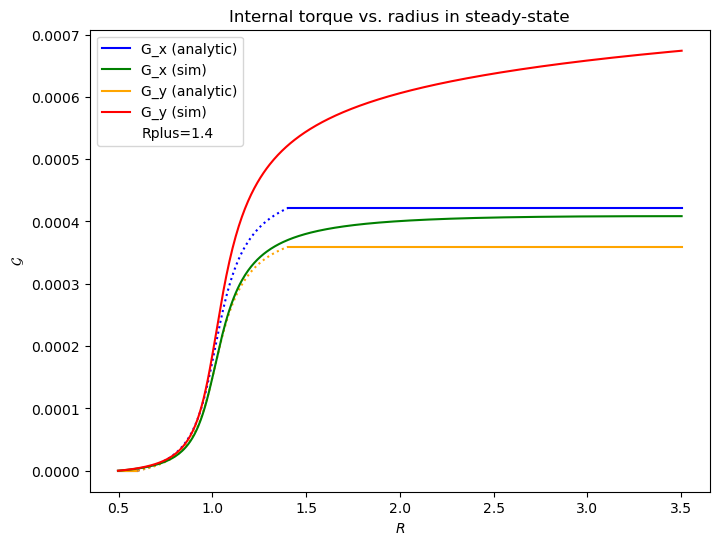

In [15]:
fig, ax = plt.subplots(figsize=(8,6))

plt.plot(Rs_inner, np.zeros(Rs_inner.shape), color="blue", ls='-')
plt.plot(Rs_inner, np.zeros(Rs_inner.shape), color="orange", ls='-')

plt.plot(Rs_mid, Gmid(Rs_mid, use_gap).real, color="blue", ls=':')
plt.plot(Rs_mid, Gmid(Rs_mid, use_gap).imag, color="orange", ls=':')

if load_data:
    plt.plot(Rs_outer, Gouter(Rs_outer, use_gap).real, color="blue", ls='-', label="G_x (analytic)")
    plt.plot(Rs_torque_ss, Gs_ss.real, color="green", label="G_x (sim)")
    plt.plot(Rs_outer, Gouter(Rs_outer, use_gap).imag, color="orange", ls='-', label="G_y (analytic)")
    plt.plot(Rs_torque_ss, Gs_ss.imag, color="red", label="G_y (sim)")
else:
    plt.plot(Rs_outer, Gouter(Rs_outer, use_gap).real, color="blue", ls='-', label="G_x (analytic)")
    plt.plot(Rs_outer, Gouter(Rs_outer, use_gap).imag, color="orange", ls='-', label="G_y (analytic)")

if use_gap:
    R_a, R_b = 0.5, 1.5
    ax.vlines([R_a,R_b], 0, 1, transform=ax.get_xaxis_transform(), \
                  color="black", linestyle=":")#, label="Gap edges")

plt.scatter([],[], s=0, label="Rplus=" + str(Rplus))

plt.title(r"Internal torque vs. radius in steady-state")
plt.xlabel(r"$R$")
plt.ylabel(r"$\mathcal{G}$")
plt.legend()

save_figs = True
if save_figs:
    if use_gap:
        filepath = "Figures/gapped-G_analytic_alpha=" + str(alpha) + \
        ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
            ",Rmax=" + str(Rmax) + ",Rplus=" + str(Rplus) + ".png"
    else:
        filepath = "Figures/G_analytic_alpha=" + str(alpha) + \
        ",h=" + str(cs) + ",Mp=" + str(Mp) + ",eps=" +str(soft_term) +\
            ",Rmax=" + str(Rmax) + ",Rplus=" + str(Rplus) + ".png"
    plt.savefig(filepath)

plt.show()

## [OLD - 1/12/26] plot $\mathcal{W}_\text{in}/\mathcal{W}_\text{out}$ over parameter space

Here, I'll plot $\frac{\mathcal{W}_\text{in}}{\mathcal{W}_\text{out}}$ as a function of $\frac{h}\alpha$ and $k_0 = \frac{q}{\pi \epsilon h}$.

In [25]:
h_div_alpha_ctrl = 0.02 / 0.01
k0_ctrl = 0.003 / (np.pi * 0.1 * 0.02)

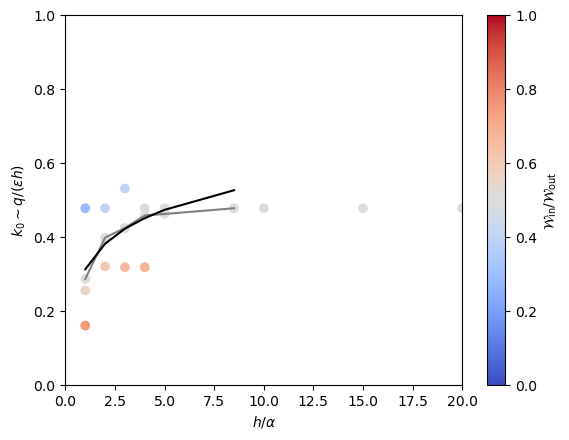

In [55]:
data_pts = np.asarray(([20, k0_ctrl, .5], # finding cutoff for k0_ctrl
                       [h_div_alpha_ctrl, k0_ctrl, .41],
                       [10, k0_ctrl, 0.5],
                       [15, k0_ctrl, 0.5],
                       [5, k0_ctrl, 0.48],
                       [5, 0.462, 0.5],
                       [8.5, k0_ctrl, 0.495], 
                       [1, k0_ctrl, 0.29], # end k0_ctrl
                       [2, 1.6, 0.02],
                       [2, 0.32, 0.61],
                       [2, 0.398, 0.5],
                       [1, 0.286, 0.51],
                       [1, 0.255, 0.56],
                       [1, 0.16, 0.75],
                       [3, 0.318, 0.66], # Mp=3e-3, h=0.03, alpha=0.01
                       [3, 0.531, 0.40], # Mp=5e-3
                       [3, 0.424, 0.52], # Mp=4e-3
                       [4, 0.318, 0.683], # Mp=4e-3, h=0.04, alpha=0.01
                       [4, 0.477, 0.476], # Mp=6e-3
                       [4, 0.458, 0.5]
                      ))

h_div_alphas = data_pts[:,0]
k0s = data_pts[:,1]
Win_div_Wouts = data_pts[:,2]

# plot the "border" between breaking and non-breaking regimes
xs_border = np.asarray([1,2,3,4,5, 8.5])
ys_border = [0.286, 0.398, 0.424, 0.458, 0.462, k0_ctrl]

plt.plot(xs_border, ys_border, color="gray")
# plt.plot(xs_border, .1*np.log(1.3*xs_border) + 0.286, color="black")

plt.scatter(h_div_alphas, k0s, c=Win_div_Wouts, vmin=0, vmax=1, cmap='coolwarm')
plt.xlabel(r"$h/\alpha$")
plt.ylabel(r"$k_0 \sim q/(\epsilon h)$")

plt.xlim(0, 20)
plt.ylim(0, 1)

plt.colorbar(label=r"$\mathcal{W}_\text{in}/\mathcal{W}_\text{out}$")

plt.show()